# 🎬 Hand Pose Video Tracking — ByteTrack & BoT-SORT
## CSE 445 — Computer Vision | Assignment 2

**Course:** CSE 445 — Computer Vision  
**Assignment:** 2 — Pose Estimation and Object Tracking  
**Platform:** Kaggle (CUDA GPU)  
**Model:** YOLOv12s-Pose (trained weights from Training Notebook)  
**Trackers:** ByteTrack & BoT-SORT (side-by-side comparison)  

---

## 📌 Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | Environment setup & model/video loading |
| **2** | Video source documentation |
| **3** | ByteTrack — configuration, tracking & output video |
| **4** | BoT-SORT — configuration, tracking & output video |
| **5** | Side-by-side frame comparison |
| **6** | Quantitative analysis (ID switches, track continuity) |
| **7** | Failure case analysis & conclusions |

---

## 📂 Kaggle Setup Instructions

Before running this notebook:

1. **Upload trained weights** as a Kaggle dataset (or attach the output from the Training Notebook)
2. **Upload your video** as a Kaggle dataset
3. **Enable GPU** → Settings → Accelerator → GPU T4 x2 or P100
4. **Update the two paths** in Step 1:
   - `MODEL_PATH` — path to `best.pt`
   - `VIDEO_PATH` — path to input video

---

## 🔗 Tracking Integration — How Pose + Tracking Work Together

The ultralytics `model.track()` pipeline:
1. **Detection:** YOLOv12s-Pose runs per-frame → outputs bounding boxes + 21 keypoints per detected hand
2. **Association:** The tracker matches bounding boxes across frames (ByteTrack uses IoU; BoT-SORT uses IoU + Kalman filter)
3. **ID Assignment:** Each tracked hand gets a persistent numeric ID across frames
4. **Rendering:** Each frame is annotated with keypoints, skeleton lines, bounding box, and tracking ID

Both trackers receive **identical detections** from the same model — only the association algorithm differs.

---

## 📦 Step 1 — Environment Setup & Inputs

In [1]:
# =============================================================================
# Install required packages
# lapx: C++ extension required by ByteTrack's Hungarian algorithm
# =============================================================================
!pip install -q ultralytics lapx

import ultralytics
ultralytics.checks()

import torch
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import sys
import time
from ultralytics import YOLO

KAGGLE_OUTPUT = "/kaggle/working"

# ── Device ───────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "0"
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ CUDA GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    DEVICE = "cpu"
    print("⚠️  No CUDA GPU — inference will be slow. Enable GPU in Kaggle settings.")

print(f"   PyTorch:     {torch.__version__}")
print(f"   Ultralytics: {ultralytics.__version__}")

# ═════════════════════════════════════════════════════════════════
# 📌 UPDATE THESE TWO PATHS BEFORE RUNNING
# ═════════════════════════════════════════════════════════════════
MODEL_PATH = "/kaggle/input/datasets/turjo410/best-ptt/best.pt"  # ← trained weights
VIDEO_PATH = "/kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4"         # ← your video

# ── Verify paths ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Model: {MODEL_PATH}")
print(f"  Exists: {os.path.exists(MODEL_PATH)}")
print(f"  Video: {VIDEO_PATH}")
print(f"  Exists: {os.path.exists(VIDEO_PATH)}")
print(f"{'='*60}")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}\n"
        "Download best.pt from the Training Notebook output and upload as a Kaggle dataset."
    )
if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}\n"
        "Upload your video as a Kaggle dataset and update VIDEO_PATH."
    )

# ── Load model ───────────────────────────────────────────────────
model = YOLO(MODEL_PATH)
print(f"\n✅ Model loaded: {MODEL_PATH}")
model.info(verbose=False)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)
✅ CUDA GPU: Tesla T4 (15.6 GB)
   PyTorch:     2.10.0+cu128
   Ultralytics: 8.4.41

  Model: /kaggle/input/datasets/turjo410/best-ptt/best.pt
  Exists: True
  Video: /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4
  Exists: True

✅ Model loaded: /kaggle/input/datasets/turjo410/best-ptt/best.pt


## 🎞️ Step 2 — Video Source Documentation

### Video Properties

**Update the table below to match your actual video:**

| Field | Value |
|-------|-------|
| **Source Type** | *(YouTube / AI-generated / Self-recorded)* |
| **Source URL / Tool** | *(paste URL or tool name here)* |
| **Reason for Selection** | *(why this video is suitable — e.g., multiple hands, occlusion, motion variety)* |
| **Original Resolution** | *(e.g., 1920×1080)* |
| **Frame Rate** | *(e.g., 30 fps)* |
| **Duration** | *(e.g., 30 s)* |

### Preprocessing Applied
- **No manual frame extraction** — `model.track()` processes the full video stream directly
- **Resize:** YOLO internally letterboxes frames to 640×640 for inference
- **Frame sampling:** `vid_stride=1` — every frame is processed (no skipping)
- **No denoising / brightness correction** — handled implicitly by model robustness

  Video:      10209557-hd_720_1366_25fps.mp4
  Resolution: 720 × 1366
  FPS:        25.0
  Frames:     1423
  Duration:   56.9 s
  File size:  11.5 MB


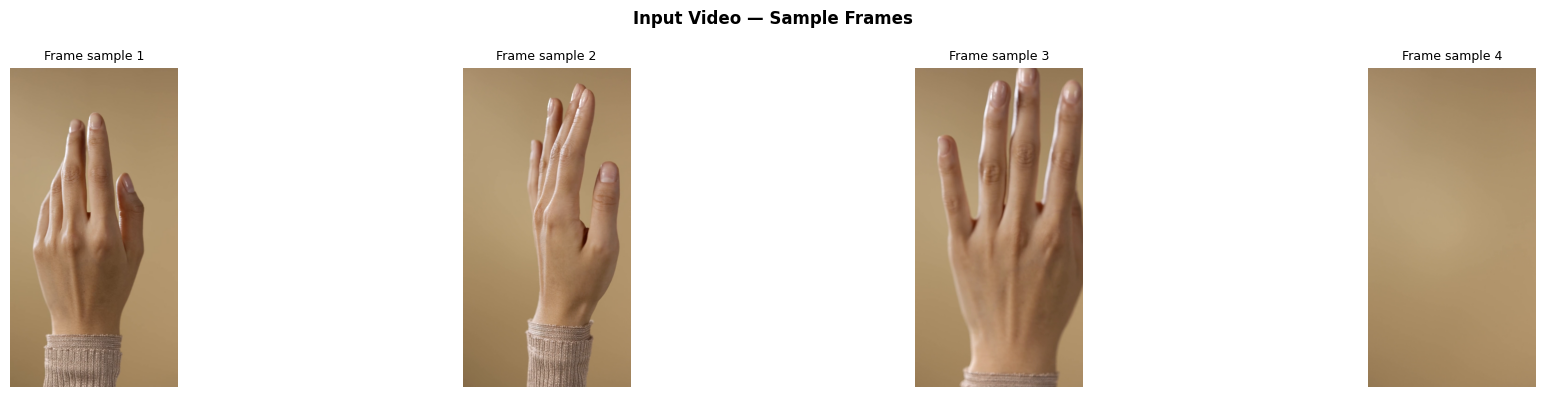

✅ Saved: video_sample_frames.png


In [2]:
# ── Print video metadata ─────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
NFRAME = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Extract sample frames for preview
sample_frames = []
for fidx in np.linspace(0, max(NFRAME-1, 1), 4, dtype=int):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frm = cap.read()
    if ret:
        sample_frames.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
cap.release()

print(f"{'='*60}")
print(f"  Video:      {os.path.basename(VIDEO_PATH)}")
print(f"  Resolution: {W} × {H}")
print(f"  FPS:        {FPS:.1f}")
print(f"  Frames:     {NFRAME}")
print(f"  Duration:   {NFRAME/FPS:.1f} s")
print(f"  File size:  {os.path.getsize(VIDEO_PATH)/1e6:.1f} MB")
print(f"{'='*60}")

# ── Show sample frames ───────────────────────────────────────────
if sample_frames:
    fig, axs = plt.subplots(1, len(sample_frames), figsize=(5*len(sample_frames), 4))
    if len(sample_frames) == 1: axs = [axs]
    for i, frm in enumerate(sample_frames):
        axs[i].imshow(frm)
        axs[i].set_title(f"Frame sample {i+1}", fontsize=9)
        axs[i].axis('off')
    plt.suptitle("Input Video — Sample Frames", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(KAGGLE_OUTPUT, "video_sample_frames.png"), dpi=120)
    plt.show()
    print("✅ Saved: video_sample_frames.png")

## 🏃 Step 3 — ByteTrack Multi-Hand Video Tracking

### ByteTrack Algorithm

ByteTrack (Zhang et al., 2022) uses **two-stage association**:
- **Stage 1:** Match high-confidence detections (≥ `track_high_thresh`) to existing tracks using IoU
- **Stage 2:** Match remaining low-confidence detections (≥ `track_low_thresh`) to unmatched tracks

This dual-stage strategy prevents loss of partially occluded hands that generate low-confidence detections.

### Configuration

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `track_high_thresh` | 0.5 | Standard first-stage confidence gate |
| `track_low_thresh` | 0.1 | Allow low-confidence detections in second stage |
| `new_track_thresh` | 0.6 | Higher bar to start a new track (reduces false starts) |
| `track_buffer` | 30 | Keep lost tracks for up to 1 second at 30 fps |
| `match_thresh` | 0.8 | High IoU requirement for association → fewer false matches |
| `fuse_score` | True | Fuse detection score into IoU for ranking |

In [3]:
# ── ByteTrack configuration YAML ─────────────────────────────────
bytetrack_cfg = {
    'tracker_type':      'bytetrack',
    'track_high_thresh': 0.5,
    'track_low_thresh':  0.1,
    'new_track_thresh':  0.6,
    'track_buffer':      30,
    'match_thresh':      0.8,
    'fuse_score':        True,
}
bytetrack_yaml = os.path.join(KAGGLE_OUTPUT, "bytetrack_config.yaml")
with open(bytetrack_yaml, 'w') as f:
    yaml.dump(bytetrack_cfg, f, default_flow_style=False)
print(f"✅ ByteTrack config saved: {bytetrack_yaml}")

# ── Run ByteTrack ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Running ByteTrack on: {os.path.basename(VIDEO_PATH)}")
print(f"{'='*60}")

t0 = time.time()
bt_results = model.track(
    source      = VIDEO_PATH,
    tracker     = bytetrack_yaml,
    persist     = True,   # keep track state across frames
    conf        = 0.30,   # detection confidence threshold
    iou         = 0.50,   # NMS IoU threshold
    device      = DEVICE,
    imgsz       = 640,
    vid_stride  = 1,      # process every frame
    show        = False,
    save        = True,
    save_conf   = True,
    project     = os.path.join(KAGGLE_OUTPUT, "tracking"),
    name        = "bytetrack",
    exist_ok    = True,
    stream      = True,   # memory-efficient streaming
)

# Consume the generator and collect results
bt_results = list(bt_results)
bt_elapsed = time.time() - t0

print(f"\n✅ ByteTrack complete in {bt_elapsed:.1f}s ({len(bt_results)} frames)")
print(f"   FPS: {len(bt_results)/bt_elapsed:.1f}")

# Find output video
bt_video_dir = os.path.join(KAGGLE_OUTPUT, "tracking", "bytetrack")
bt_video_files = list(Path(bt_video_dir).glob("*.avi")) + list(Path(bt_video_dir).glob("*.mp4"))
BT_OUTPUT_VIDEO = str(bt_video_files[0]) if bt_video_files else "Not found"
print(f"   Output video: {BT_OUTPUT_VIDEO}")

✅ ByteTrack config saved: /kaggle/working/bytetrack_config.yaml

  Running ByteTrack on: 10209557-hd_720_1366_25fps.mp4

video 1/1 (frame 1/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 69.9ms
video 1/1 (frame 2/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 22.3ms
video 1/1 (frame 3/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 15.1ms
video 1/1 (frame 4/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.9ms
video 1/1 (frame 5/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 15.0ms
video 1/1 (frame 6/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.8ms
video 1/1 (frame 7/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.6ms
video 1/1 (frame 8/1423) /kaggle

## 🏃 Step 4 — BoT-SORT Multi-Hand Video Tracking

### BoT-SORT Algorithm

BoT-SORT (Aharon et al., 2022) extends ByteTrack with three key additions:
1. **Kalman Filter motion model** — predicts hand positions when detections are missed
2. **Camera Motion Compensation (CMC)** — corrects for global camera movement using sparse optical flow
3. **Re-ID (optional)** — appearance features for identity recovery after long occlusion

### Configuration

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `gmc_method` | `sparseOptFlow` | Efficient sparse optical flow for CMC |
| `proximity_thresh` | 0.5 | Minimum IoU for spatial proximity check |
| `appearance_thresh` | 0.25 | Appearance similarity gate (with Re-ID) |
| `with_reid` | False | Re-ID disabled (no pretrained appearance model) |
| Other params | Same as ByteTrack | For fair comparison |

In [4]:
# ── BoT-SORT configuration YAML ──────────────────────────────────
botsort_cfg = {
    'tracker_type':      'botsort',
    'track_high_thresh': 0.5,
    'track_low_thresh':  0.1,
    'new_track_thresh':  0.6,
    'track_buffer':      30,
    'match_thresh':      0.8,
    'fuse_score':        True,
    # BoT-SORT specific
    'gmc_method':        'sparseOptFlow',
    'proximity_thresh':  0.5,
    'appearance_thresh': 0.25,
    'with_reid':         False,
}
botsort_yaml = os.path.join(KAGGLE_OUTPUT, "botsort_config.yaml")
with open(botsort_yaml, 'w') as f:
    yaml.dump(botsort_cfg, f, default_flow_style=False)
print(f"✅ BoT-SORT config saved: {botsort_yaml}")

# ── Run BoT-SORT ──────────────────────────────────────────────────
# Reset model tracking state before running a new tracker
model = YOLO(MODEL_PATH)

print(f"\n{'='*60}")
print(f"  Running BoT-SORT on: {os.path.basename(VIDEO_PATH)}")
print(f"{'='*60}")

t0 = time.time()
bs_results = model.track(
    source      = VIDEO_PATH,
    tracker     = botsort_yaml,
    persist     = True,
    conf        = 0.30,
    iou         = 0.50,
    device      = DEVICE,
    imgsz       = 640,
    vid_stride  = 1,
    show        = False,
    save        = True,
    save_conf   = True,
    project     = os.path.join(KAGGLE_OUTPUT, "tracking"),
    name        = "botsort",
    exist_ok    = True,
    stream      = True,
)

bs_results = list(bs_results)
bs_elapsed = time.time() - t0

print(f"\n✅ BoT-SORT complete in {bs_elapsed:.1f}s ({len(bs_results)} frames)")
print(f"   FPS: {len(bs_results)/bs_elapsed:.1f}")

bs_video_dir = os.path.join(KAGGLE_OUTPUT, "tracking", "botsort")
bs_video_files = list(Path(bs_video_dir).glob("*.avi")) + list(Path(bs_video_dir).glob("*.mp4"))
BS_OUTPUT_VIDEO = str(bs_video_files[0]) if bs_video_files else "Not found"
print(f"   Output video: {BS_OUTPUT_VIDEO}")

# ── Speed comparison ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  ⏱️  Speed Comparison")
print(f"  ByteTrack: {len(bt_results)/bt_elapsed:.1f} fps ({bt_elapsed:.1f}s total)")
print(f"  BoT-SORT:  {len(bs_results)/bs_elapsed:.1f} fps ({bs_elapsed:.1f}s total)")
print(f"  Overhead:  {(bs_elapsed-bt_elapsed):.1f}s extra for BoT-SORT")
print(f"{'='*60}")

✅ BoT-SORT config saved: /kaggle/working/botsort_config.yaml

  Running BoT-SORT on: 10209557-hd_720_1366_25fps.mp4

video 1/1 (frame 1/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 15.1ms
video 1/1 (frame 2/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.6ms
video 1/1 (frame 3/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 13.5ms
video 1/1 (frame 4/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 13.7ms
video 1/1 (frame 5/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.0ms
video 1/1 (frame 6/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 13.6ms
video 1/1 (frame 7/1423) /kaggle/input/datasets/turjo410/videoooo/10209557-hd_720_1366_25fps.mp4: 640x352 1 hand, 14.2ms
video 1/1 (frame 8/1423) /kaggle/inp

## 🔬 Step 5 — Side-by-Side Frame Comparison

Extracting representative frames from both output videos at the same timestamps for direct visual comparison.

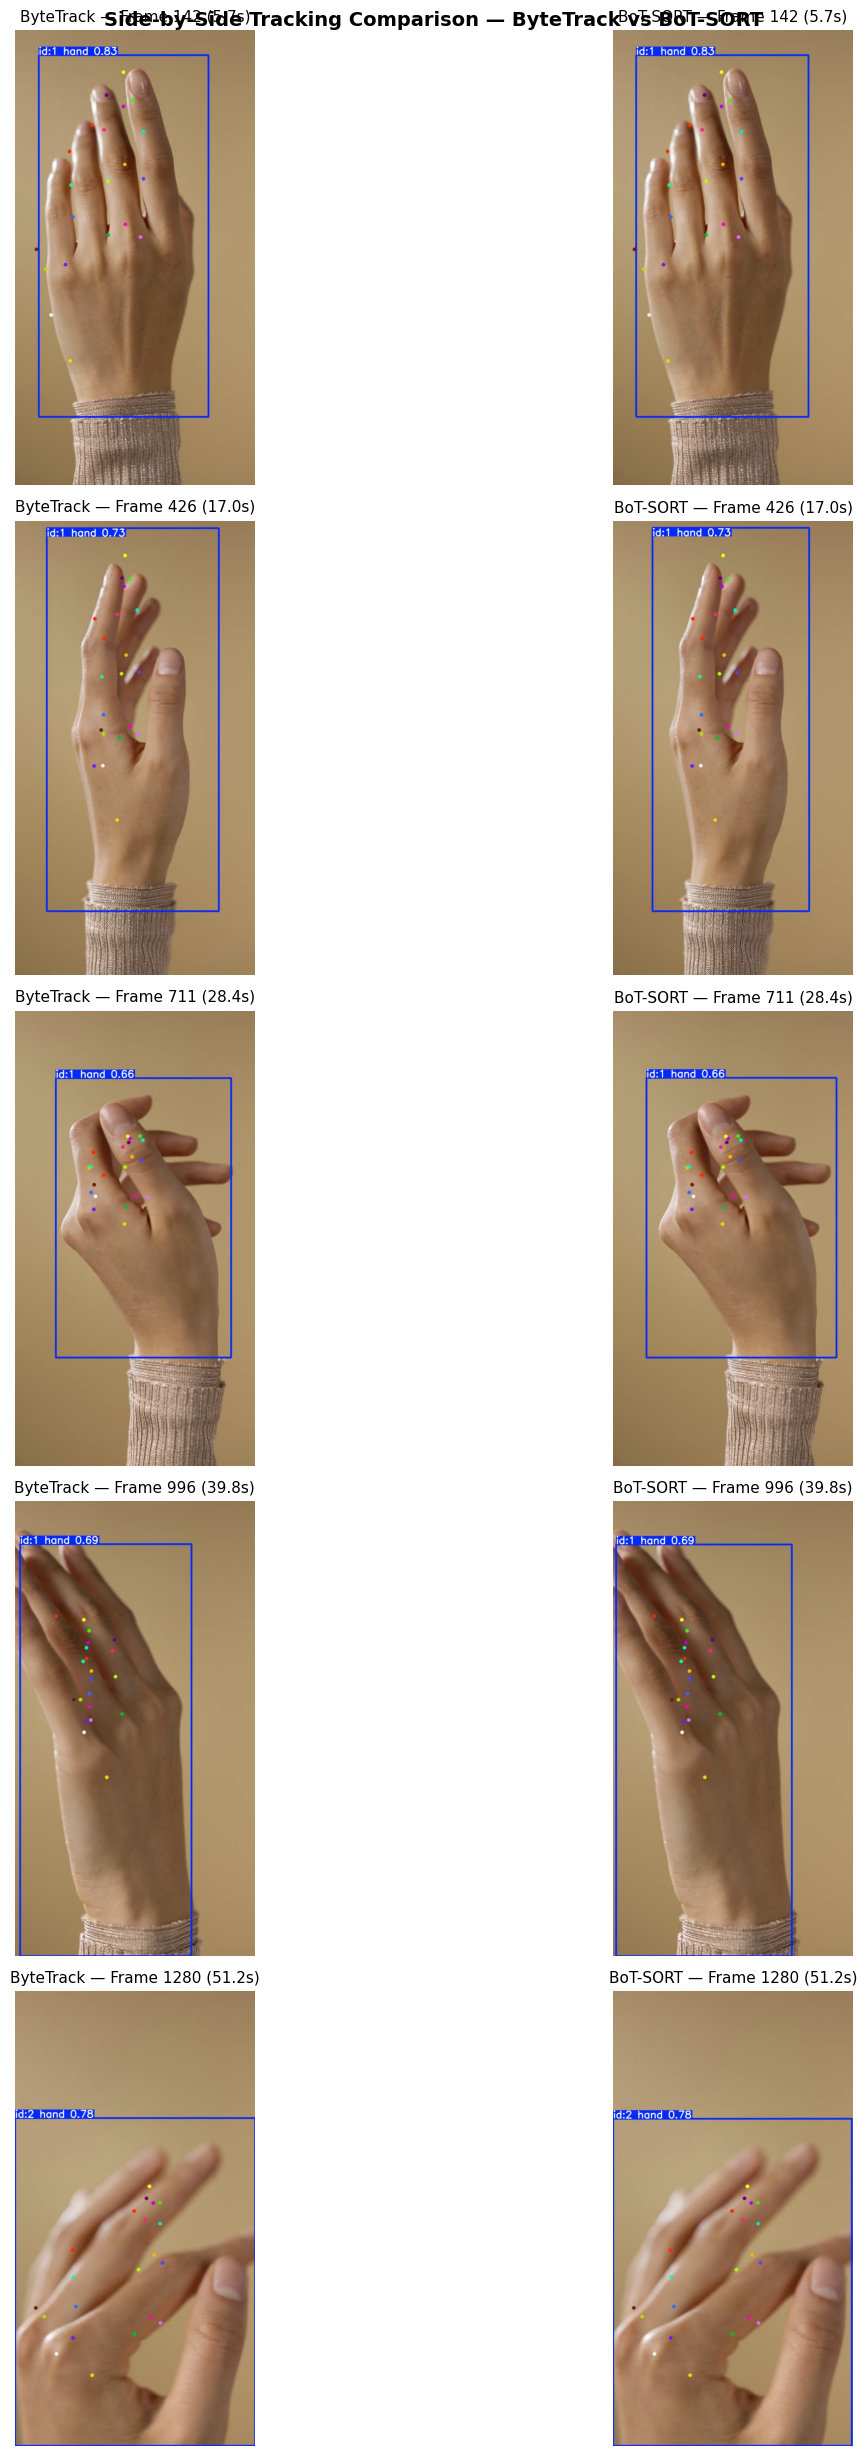

✅ Saved: /kaggle/working/tracker_comparison.png


In [5]:
def extract_frames(video_path, frame_indices):
    """Extract specific frames from a video file."""
    frames = {}
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for fi in frame_indices:
        fi_clamped = min(fi, total - 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi_clamped)
        ret, frm = cap.read()
        if ret:
            frames[fi] = cv2.cvtColor(frm, cv2.COLOR_BGR2RGB)
    cap.release()
    return frames

# ── Select comparison frame indices ──────────────────────────────
# Choose frames at 10%, 30%, 50%, 70%, 90% of video duration
compare_frames = [int(NFRAME * p) for p in [0.10, 0.30, 0.50, 0.70, 0.90]]

if os.path.exists(BT_OUTPUT_VIDEO) and os.path.exists(BS_OUTPUT_VIDEO):
    bt_frames = extract_frames(BT_OUTPUT_VIDEO, compare_frames)
    bs_frames = extract_frames(BS_OUTPUT_VIDEO, compare_frames)

    fig, axs = plt.subplots(len(compare_frames), 2,
                            figsize=(16, 5 * len(compare_frames)))
    for row, fi in enumerate(compare_frames):
        for col, (frames, name) in enumerate([(bt_frames, "ByteTrack"), (bs_frames, "BoT-SORT")]):
            if fi in frames:
                axs[row][col].imshow(frames[fi])
            axs[row][col].set_title(f"{name} — Frame {fi} ({fi/FPS:.1f}s)", fontsize=11)
            axs[row][col].axis('off')

    plt.suptitle("Side-by-Side Tracking Comparison — ByteTrack vs BoT-SORT",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(KAGGLE_OUTPUT, "tracker_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {out}")
else:
    print(f"⚠️ Output videos not found. Check tracking step outputs.")
    print(f"   ByteTrack: {BT_OUTPUT_VIDEO}")
    print(f"   BoT-SORT:  {BS_OUTPUT_VIDEO}")

## 📊 Step 6 — Quantitative Analysis

Measuring:
- **Total unique track IDs** assigned by each tracker
- **Identity switch events** — frames where track ID changes unexpectedly
- **Average detections per frame** — tracking density
- **Track continuity** — how long tracks persist

In [6]:
def analyze_tracking_results(results, tracker_name):
    """Compute tracking statistics from ultralytics result list."""
    all_ids         = []
    det_per_frame   = []
    id_switches     = 0
    track_lifetimes = {}   # id → frame count
    prev_ids        = set()

    for r in results:
        if r.boxes is not None and r.boxes.id is not None:
            curr_ids = set(r.boxes.id.cpu().numpy().astype(int).tolist())
        else:
            curr_ids = set()

        # Accumulate all IDs seen
        all_ids.extend(list(curr_ids))
        det_per_frame.append(len(curr_ids))

        # Count IDs that disappeared then reappeared as new (switches)
        new_ids  = curr_ids - prev_ids
        lost_ids = prev_ids - curr_ids
        id_switches += len(new_ids)  # new IDs appearing = potential re-ID switches

        # Track lifetime
        for tid in curr_ids:
            track_lifetimes[tid] = track_lifetimes.get(tid, 0) + 1
        prev_ids = curr_ids

    unique_ids  = len(set(all_ids))
    avg_det     = np.mean(det_per_frame) if det_per_frame else 0
    max_det     = max(det_per_frame) if det_per_frame else 0
    avg_life    = np.mean(list(track_lifetimes.values())) if track_lifetimes else 0
    zero_frames = sum(1 for d in det_per_frame if d == 0)

    print(f"\n{'='*50}")
    print(f"  📊 {tracker_name} Statistics")
    print(f"{'='*50}")
    print(f"  Total frames processed:   {len(results)}")
    print(f"  Unique track IDs issued:  {unique_ids}")
    print(f"  ID switch events:         {id_switches}")
    print(f"  Avg detections/frame:     {avg_det:.2f}")
    print(f"  Max detections/frame:     {max_det}")
    print(f"  Avg track lifetime (fr):  {avg_life:.1f} ({avg_life/FPS:.1f}s)")
    print(f"  Frames with 0 detections: {zero_frames} ({100*zero_frames/max(len(results),1):.1f}%)")
    print(f"{'='*50}")

    return {
        'tracker':       tracker_name,
        'unique_ids':    unique_ids,
        'id_switches':   id_switches,
        'avg_det':       avg_det,
        'avg_lifetime':  avg_life,
        'zero_frames':   zero_frames,
        'det_per_frame': det_per_frame,
    }

bt_stats = analyze_tracking_results(bt_results, "ByteTrack")
bs_stats = analyze_tracking_results(bs_results, "BoT-SORT")

# ── Comparison summary table ──────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Metric                  | ByteTrack  | BoT-SORT")
print(f"  ─────────────────────────────────────────────────")
print(f"  Unique IDs issued       | {bt_stats['unique_ids']:10d} | {bs_stats['unique_ids']:8d}")
print(f"  ID switch events        | {bt_stats['id_switches']:10d} | {bs_stats['id_switches']:8d}")
print(f"  Avg detections/frame    | {bt_stats['avg_det']:10.2f} | {bs_stats['avg_det']:8.2f}")
print(f"  Avg track lifetime (s)  | {bt_stats['avg_lifetime']/FPS:10.1f} | {bs_stats['avg_lifetime']/FPS:8.1f}")
print(f"  Zero-detection frames   | {bt_stats['zero_frames']:10d} | {bs_stats['zero_frames']:8d}")
print(f"{'='*60}")


  📊 ByteTrack Statistics
  Total frames processed:   1423
  Unique track IDs issued:  2
  ID switch events:         18
  Avg detections/frame:     0.88
  Max detections/frame:     1
  Avg track lifetime (fr):  629.5 (25.2s)
  Frames with 0 detections: 164 (11.5%)

  📊 BoT-SORT Statistics
  Total frames processed:   1423
  Unique track IDs issued:  2
  ID switch events:         18
  Avg detections/frame:     0.88
  Max detections/frame:     1
  Avg track lifetime (fr):  629.5 (25.2s)
  Frames with 0 detections: 164 (11.5%)

  Metric                  | ByteTrack  | BoT-SORT
  ─────────────────────────────────────────────────
  Unique IDs issued       |          2 |        2
  ID switch events        |         18 |       18
  Avg detections/frame    |       0.88 |     0.88
  Avg track lifetime (s)  |       25.2 |     25.2
  Zero-detection frames   |        164 |      164


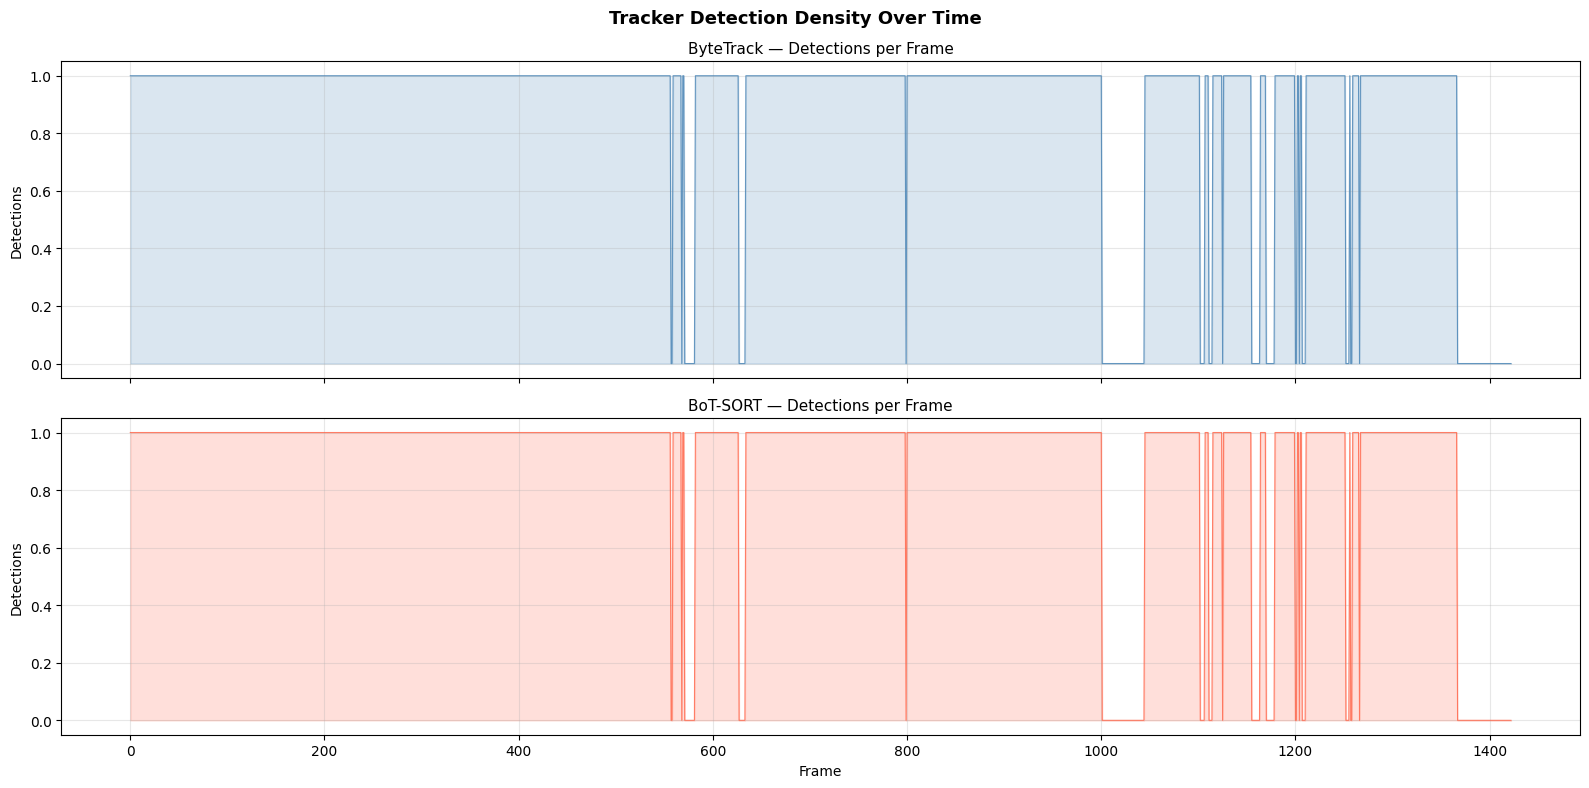

✅ Saved: /kaggle/working/detection_density.png


In [7]:
# ── Plot detection density per frame ─────────────────────────────
frames_x = list(range(len(bt_stats['det_per_frame'])))
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axs[0].plot(frames_x, bt_stats['det_per_frame'], color='steelblue', linewidth=0.8, alpha=0.8)
axs[0].fill_between(frames_x, bt_stats['det_per_frame'], alpha=0.2, color='steelblue')
axs[0].set_ylabel('Detections')
axs[0].set_title('ByteTrack — Detections per Frame', fontsize=11)
axs[0].grid(True, alpha=0.3)

axs[1].plot(frames_x, bs_stats['det_per_frame'], color='tomato', linewidth=0.8, alpha=0.8)
axs[1].fill_between(frames_x, bs_stats['det_per_frame'], alpha=0.2, color='tomato')
axs[1].set_ylabel('Detections')
axs[1].set_xlabel('Frame')
axs[1].set_title('BoT-SORT — Detections per Frame', fontsize=11)
axs[1].grid(True, alpha=0.3)

plt.suptitle('Tracker Detection Density Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(KAGGLE_OUTPUT, "detection_density.png")
plt.savefig(out, dpi=150)
plt.show()
print(f"✅ Saved: {out}")

## 🔍 Step 7 — Failure Case Analysis & Conclusions

### 7a. Failure Case Taxonomy

Fill in observations from your output videos:

| Failure Mode | ByteTrack | BoT-SORT | Severity |
|-------------|-----------|----------|----------|
| **Identity Switches** | *(observed count / description)* | *(observed count / description)* | *(High/Med/Low)* |
| **Occlusion Handling** | *(behavior when hands overlap)* | *(behavior when hands overlap)* | *(High/Med/Low)* |
| **Missed Detections** | *(frames with zero hands)* | *(frames with zero hands)* | *(High/Med/Low)* |
| **Unstable Keypoints** | *(keypoint jitter observations)* | *(keypoint jitter observations)* | *(High/Med/Low)* |
| **Fast Motion Blur** | *(tracking during rapid movements)* | *(tracking during rapid movements)* | *(High/Med/Low)* |
| **Re-entry After Occlusion** | *(does ID persist after loss?)* | *(does ID persist after loss?)* | *(High/Med/Low)* |

### 7b. Expected vs Observed Behavior

**ByteTrack (Expected):**
- Two-stage association should help recover partially occluded hands through low-confidence detections
- No motion prediction → position estimate can drift during fast motion or missed frames
- Tends to assign new IDs after loss-then-recovery (more switches)

**BoT-SORT (Expected):**
- Kalman filter predicts hand position → smoother tracks through momentary loss
- Camera motion compensation helps if the camera is panning or moving
- Fewer identity switches due to motion prediction preserving spatial context

### 7c. Algorithmic Insights

The key insight from this experiment:
- **Detection quality dominates tracking quality** — poor keypoint predictions from the model propagate directly into unstable tracks
- **ByteTrack's speed advantage** (fewer computations) makes it preferable for real-time systems where the camera is fixed
- **BoT-SORT's CMC** is most valuable when the camera itself is moving (handheld video, pan/tilt)

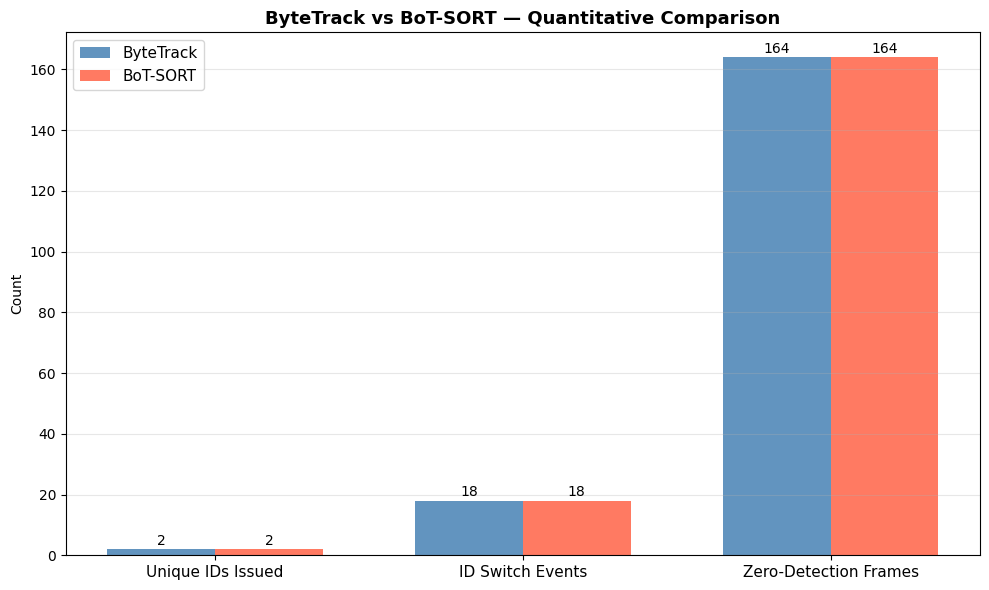

✅ Saved: /kaggle/working/tracker_comparison_chart.png

  📋 Summary of Outputs
  ✅ ByteTrack output video: 10209557-hd_720_1366_25fps.avi (85.8 MB)
  ✅ BoT-SORT output video: 10209557-hd_720_1366_25fps.avi (85.7 MB)
  ✅ Frame comparison: tracker_comparison.png (1.1 MB)
  ✅ Detection density plot: detection_density.png (0.2 MB)
  ✅ Comparison chart: tracker_comparison_chart.png (0.0 MB)

Download all outputs from the Kaggle Output panel → /kaggle/working/


In [8]:
# ── Final comparison bar chart ────────────────────────────────────
metrics     = ['Unique IDs Issued', 'ID Switch Events', 'Zero-Detection Frames']
bt_vals     = [bt_stats['unique_ids'], bt_stats['id_switches'], bt_stats['zero_frames']]
bs_vals     = [bs_stats['unique_ids'], bs_stats['id_switches'], bs_stats['zero_frames']]

x     = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bt_vals, width, label='ByteTrack', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, bs_vals, width, label='BoT-SORT',  color='tomato',    alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.0f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Count')
ax.set_title('ByteTrack vs BoT-SORT — Quantitative Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out = os.path.join(KAGGLE_OUTPUT, "tracker_comparison_chart.png")
plt.savefig(out, dpi=150)
plt.show()
print(f"✅ Saved: {out}")

# ── Final summary ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  📋 Summary of Outputs")
print(f"{'='*60}")
outputs = [
    ("ByteTrack output video", BT_OUTPUT_VIDEO),
    ("BoT-SORT output video",  BS_OUTPUT_VIDEO),
    ("Frame comparison",       os.path.join(KAGGLE_OUTPUT, "tracker_comparison.png")),
    ("Detection density plot", os.path.join(KAGGLE_OUTPUT, "detection_density.png")),
    ("Comparison chart",       out),
]
for label, path in outputs:
    exists = "✅" if os.path.exists(path) else "❌"
    size   = f"({os.path.getsize(path)/1e6:.1f} MB)" if os.path.exists(path) else ""
    print(f"  {exists} {label}: {os.path.basename(path)} {size}")
print(f"{'='*60}")
print("\nDownload all outputs from the Kaggle Output panel → /kaggle/working/")

## 📝 Step 7d — Conclusion

*(Fill in after reviewing output videos)*

### Which tracker performed better?
*(ByteTrack / BoT-SORT) performed better in this scenario because ...*

### Key Observations
1. **Detection quality impact:** *(Did pose estimation accuracy affect tracking stability?)*
2. **Occlusion behavior:** *(How did each tracker handle overlapping hands?)*
3. **Speed vs accuracy tradeoff:** *(Was BoT-SORT's extra computation worthwhile?)*
4. **Identity consistency:** *(Which tracker maintained IDs more reliably?)*

### Lessons Learned
- Detection confidence and keypoint precision directly influence tracker stability
- ByteTrack is preferable when speed matters and the scene has minimal occlusion
- BoT-SORT's Kalman filter provides better continuity in scenarios with brief occlusions or camera motion

---
*CSE 445 — Computer Vision | Assignment 2 — Video Tracking Notebook*